<a href="https://colab.research.google.com/github/husnain572/Supervised-Machine-Learning/blob/main/06_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

## Table of Contents
1. **Introduction to Linear Regression**
2. **Key Concepts**
3. **Mathematical Foundation**
4. **Assumptions of Linear Regression**
5. **Types of Linear Regression**
6. **How Linear Regression Works**
7. **Cost Function**
8. **Gradient Descent**
9. **Evaluating the Model**
10. **Advantages and Disadvantages**
11. **Applications of Linear Regression**
12. **Conclusion**

---

## 1. Introduction to Linear Regression

Linear Regression is one of the simplest and most widely used statistical techniques in Machine Learning for predictive modeling. It is used to predict a continuous outcome variable (dependent variable) based on one or more predictor variables (independent variables). The relationship between the dependent and independent variables is assumed to be linear.

### Example:
- Predicting house prices based on features like size, location, and number of bedrooms.
- Estimating the sales of a product based on advertising spend.

---

## 2. Key Concepts

- **Dependent Variable (Y):** The variable we are trying to predict (e.g., house price).
- **Independent Variable (X):** The variable used to make predictions (e.g., size of the house).
- **Linear Relationship:** A straight-line relationship between X and Y.
- **Slope (m):** The change in Y for a unit change in X.
- **Intercept (b):** The value of Y when X is 0.

---

## 3. Mathematical Foundation

The linear regression model is represented by the equation:
$$
Y = mX + b
$$
Where:
- \( Y \) = Dependent variable
- \( X \) = Independent variable
- \( m \) = Slope of the line
- \( b \) = Y-intercept

In multiple linear regression (with more than one independent variable), the equation becomes:
$$
Y = b0 + b1X1 + b2X2 +...+ bnXn
$$

Where:
- \( b0 \) = Intercept
- \( b1, b2,...,bn \) = Coefficients for each independent variable

---

## 4. Assumptions of Linear Regression

For linear regression to work effectively, certain assumptions must be met:
1. **Linearity:** The relationship between X and Y is linear.
2. **Independence:** Observations are independent of each other.
3. **Homoscedasticity:** The variance of residuals is constant across all levels of X.
4. **Normality:** Residuals are normally distributed.
5. **No Multicollinearity:** Independent variables are not highly correlated with each other.

---

## 5. Types of Linear Regression

1. **Simple Linear Regression:** Only one independent variable is used to predict the dependent variable.
   - Equation:
   $$ Y = mX + b $$
2. **Multiple Linear Regression:** Two or more independent variables are used to predict the dependent variable.
   - Equation: $$ Y = b_0 + b_1X_1 + b_2X_2 + ... + b_nX_n $$

---

## 6. How Linear Regression Works

1. **Data Collection:** Gather data with known values of X and Y.
2. **Model Training:** Use the data to find the best-fitting line (i.e., find the values of \( m \) and \( b \)).
3. **Prediction:** Use the model to predict Y for new values of X.

---

## 7. Cost Function

The cost function (or loss function) measures how well the model is performing. For linear regression, the most common cost function is the **Mean Squared Error (MSE)**:

The goal is to minimize the MSE.

---

## 8. Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function. It works by iteratively adjusting the parameters (\( m \) and \( b \)) to reduce the error.

---

## 9. Evaluating the Model

After training the model, it’s important to evaluate its performance. Common metrics include:

1. **R-squared (R²):** Measures the proportion of variance in Y that is predictable from X. Ranges from 0 to 1 (higher is better).
2. **Mean Absolute Error (MAE):** Average absolute difference between actual and predicted values.
3. **Root Mean Squared Error (RMSE):** Square root of the average squared differences between actual and predicted values.

---

## 10. Advantages and Disadvantages

### Advantages:
- Simple to understand and implement.
- Works well when the relationship between variables is linear.
- Fast to train on large datasets.

### Disadvantages:
- Assumes a linear relationship, which may not always be true.
- Sensitive to outliers.
- Cannot handle complex relationships between variables.

---

## 11. Applications of Linear Regression

- **Economics:** Predicting GDP, inflation, etc.
- **Finance:** Stock price prediction, risk assessment.
- **Healthcare:** Predicting patient outcomes based on treatment.
- **Marketing:** Estimating sales based on advertising spend.
- **Real Estate:** Predicting house prices.

---

## 12. Conclusion

Linear Regression is a foundational algorithm in Machine Learning that is easy to understand and implement. It is best suited for problems where the relationship between variables is linear. However, it has limitations when dealing with complex, non-linear relationships. By understanding its assumptions, strengths, and weaknesses, you can effectively apply linear regression to a wide range of real-world problems.



In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot

In [5]:
df=pd.read_csv("Salary_Data.csv")
df.head().style.background_gradient()

,YearsExperience,Salary
0,0.500000,28740
1,1.000000,29085
2,1.500000,33693
3,2.000000,38569
4,2.500000,35548


- We have just two columns `YearsExperience` and `Salary`. Both the variables are numerical.

In [7]:
# to see information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  40 non-null     float64
 1   Salary           40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [11]:
# to check the null values in dataset
print(df.isnull().sum().sum())

0


- There is no null value in dataset.
- Statistical analysis of the dataset like no: of observation, mean, standard deviation and interquartile value can be done using the dataset. describe().

In [12]:
df.describe().style.background_gradient()

,YearsExperience,Salary
count,40.000000,40.000000
mean,10.250000,70469.200000
std,5.845226,25736.864138
min,0.500000,28740.000000
25%,5.375000,48936.000000
50%,10.250000,70133.000000
75%,15.125000,91955.000000
max,20.000000,115591.000000


<Axes: >

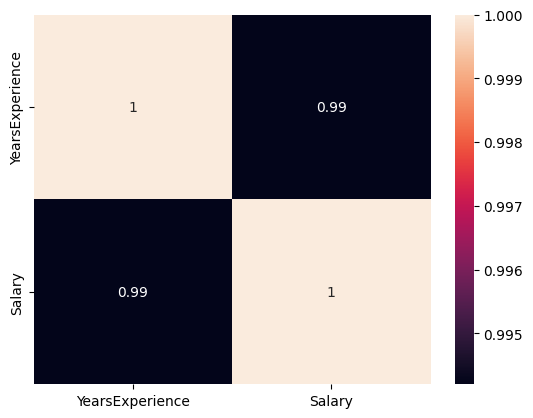

In [13]:
sns.heatmap(df.corr(),annot=True)


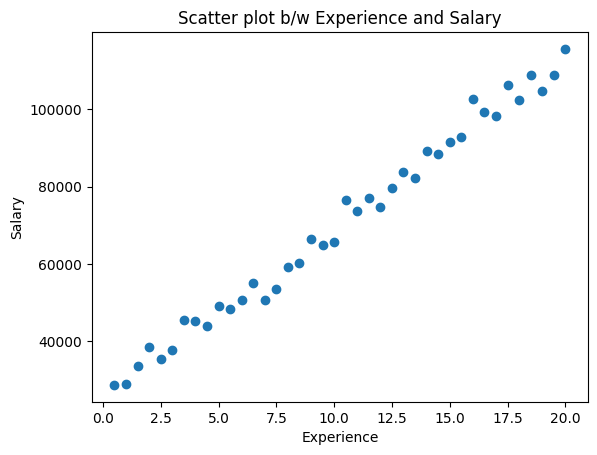

In [15]:
plt.scatter(x=df['YearsExperience'], y=df['Salary'])
plt.title("Scatter plot b/w Experience and Salary")
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

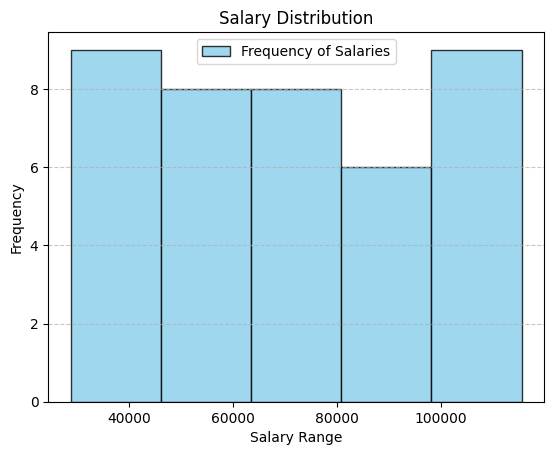

In [24]:
plt.hist(x=df['Salary'], bins=5, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Salary Distribution")
plt.xlabel("Salary Range")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(["Frequency of Salaries"])
plt.show()


In [25]:
X=df.iloc[:,:-1]
y=df.iloc[:,1]


In [27]:
print(X)
print("-------------------")


    YearsExperience
0               0.5
1               1.0
2               1.5
3               2.0
4               2.5
5               3.0
6               3.5
7               4.0
8               4.5
9               5.0
10              5.5
11              6.0
12              6.5
13              7.0
14              7.5
15              8.0
16              8.5
17              9.0
18              9.5
19             10.0
20             10.5
21             11.0
22             11.5
23             12.0
24             12.5
25             13.0
26             13.5
27             14.0
28             14.5
29             15.0
30             15.5
31             16.0
32             16.5
33             17.0
34             17.5
35             18.0
36             18.5
37             19.0
38             19.5
39             20.0
-------------------


In [28]:
print(y)
print("-------------------")


0      28740
1      29085
2      33693
3      38569
4      35548
5      37798
6      45488
7      45302
8      43842
9      49128
10     48360
11     50603
12     54976
13     50760
14     53575
15     59313
16     60212
17     66443
18     65026
19     65763
20     76647
21     73823
22     76953
23     74726
24     79617
25     83833
26     82297
27     89127
28     88448
29     91625
30     92945
31    102557
32     99210
33     98327
34    106218
35    102337
36    108877
37    104621
38    108765
39    115591
Name: Salary, dtype: int64
-------------------


## Splitting Dataset

In [29]:
#Splitting testdata into X_train,X_test,y_train,y_test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.33,random_state=2)



In [30]:
print(X_train)


    YearsExperience
16              8.5
1               1.0
33             17.0
23             12.0
25             13.0
19             10.0
32             16.5
10              5.5
4               2.5
6               3.5
3               2.0
34             17.5
5               3.0
28             14.5
20             10.5
26             13.5
39             20.0
21             11.0
35             18.0
31             16.0
7               4.0
11              6.0
18              9.5
22             11.5
8               4.5
15              8.0


In [31]:
print(X_test)


    YearsExperience
27             14.0
9               5.0
14              7.5
0               0.5
2               1.5
30             15.5
13              7.0
36             18.5
17              9.0
37             19.0
38             19.5
29             15.0
24             12.5
12              6.5


In [32]:
print(y_train)


16     60212
1      29085
33     98327
23     74726
25     83833
19     65763
32     99210
10     48360
4      35548
6      45488
3      38569
34    106218
5      37798
28     88448
20     76647
26     82297
39    115591
21     73823
35    102337
31    102557
7      45302
11     50603
18     65026
22     76953
8      43842
15     59313
Name: Salary, dtype: int64


In [33]:
print(y_test)

27     89127
9      49128
14     53575
0      28740
2      33693
30     92945
13     50760
36    108877
17     66443
37    104621
38    108765
29     91625
24     79617
12     54976
Name: Salary, dtype: int64


In [34]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

## Predict

In [35]:
y_pred=model.predict(X_test)
y_pred


array([ 87332.93076107,  47494.62792211,  58560.82315515,  27575.47650263,
        32001.95459585,  93972.6479009 ,  56347.58410855, 107252.08218056,
        65200.54029498, 109465.32122717, 111678.56027377,  91759.40885429,
        80693.21362125,  54134.34506194])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



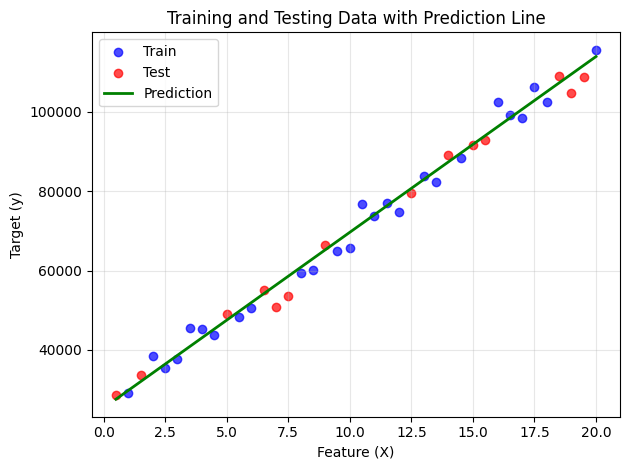

In [37]:
x_range = np.linspace(X.min(), X.max(), 100)
y_range = model.predict(x_range.reshape(-1, 1))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Train', alpha=0.7)

# Plot the testing data
plt.scatter(X_test, y_test, color='red', label='Test', alpha=0.7)

# Plot the prediction line
plt.plot(x_range, y_range, color='green', label='Prediction', linewidth=2)

# Add title and labels
plt.title("Training and Testing Data with Prediction Line")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()

plt.grid(alpha=0.3)  # Add a grid for better readability
plt.tight_layout()
plt.show()


In [38]:
m=model.coef_
print("Coefficient  :" , m)

Coefficient  : [4426.47809322]


In [39]:
#Assigning Y-intercept to c
c = model.intercept_
print("Intercept : ", c)

Intercept :  25362.23745601775


## Predicting Unknown Values
For this model, the linear regression equation will be:

Predicted Salary=Coefficient × (years of experience) + Intercept

For Years of Experience 11, predicted salary can be calculated as:

_ × (11) + _ = _

y(11) can be predicted with the model as below.


In [40]:
# y_pred=9512.94498763*(yearOfExperience)+23707.81324657549
# y_pred=mx+c
9512.94498763*11+23707.81324657549

128350.2081105055

In [41]:
model.predict([[11]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([74053.49648142])

## Evaluation
Mean Squared Error (MSE) is one of the regression evaluation metrics. It is calculated as the average squared difference between the predicted values and the real value. MSE can be calculated from the metrics module of Scikit-learn library.

In [ ]:
#Mean Squared Error (MSE)
from sklearn import metrics
print('Mean Squared Error (MSE)  : ', metrics.mean_squared_error(y_test, y_pred))
from sklearn.metrics import r2_score
print("R2 Score: ",r2_score(y_train, model.predict(X_train)))

Mean Squared Error (MSE)  :  60451409.832681164
R2 Score:  0.9716432514943859
